In [5]:
# ================================================ #
# 05 - Model Fine-Tuning with Larger Validation Set #
# ================================================ #

'''
    ## Objectives of Notebook 05 (PFA - Engineer School)

    - Use the new larger validation set (316 images)
    - Fine-tune our existing best_model.h5 (ResNet50)
    - Unfreeze the last layers + use lower learning rate
    - Apply stronger augmentation on minority class (Normal)
    - Try to improve AUC and accuracy to reach Cahier des Charges targets (>90% acc, >0.92 AUC)

    We are improving the previous model, not starting from scratch.
'''

print("Notebook 05 - Fine-tuning started")

Notebook 05 - Fine-tuning started


In [6]:
import tensorflow as tf

DATA_DIR = "../data/raw/chest_xray"

# Stronger augmentation (especially useful for Normal class)
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# Generators with new larger validation set
train_generator = train_datagen.flow_from_directory(
    directory=DATA_DIR + "/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    directory=DATA_DIR + "/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

class_weight = {0: 1.9448, 1: 0.6730}

print("✅ Generators created with larger validation set (316 images)")
print("✅ Stronger augmentation applied")

Found 4916 images belonging to 2 classes.
Found 316 images belonging to 2 classes.
✅ Generators created with larger validation set (316 images)
✅ Stronger augmentation applied


In [7]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

# ====================== LOAD EXISTING BEST MODEL ======================
model = load_model("best_model.h5")   # ← We are using our previous trained model

print("✅ best_model.h5 loaded successfully for fine-tuning")

# ====================== UNFREEZE LAST 50 LAYERS ======================
# Unfreeze the last 50 layers of ResNet50 base
for layer in model.layers:
    if hasattr(layer, 'layers'):        # This is the ResNet50 base
        for base_layer in layer.layers[:-50]:
            base_layer.trainable = False
        for base_layer in layer.layers[-50:]:
            base_layer.trainable = True
    else:
        layer.trainable = True

# ====================== RECOMPILE WITH LOWER LR ======================
model.compile(
    optimizer=Adam(learning_rate=1e-4),   # Lower learning rate for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("✅ Last 50 layers unfrozen")
print("✅ Model recompiled with lower learning rate (1e-4)")

✅ best_model.h5 loaded successfully for fine-tuning
✅ Last 50 layers unfrozen
✅ Model recompiled with lower learning rate (1e-4)


In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint("best_model_finetuned.h5", 
                    save_best_only=True, 
                    monitor='val_auc', 
                    mode='max', 
                    verbose=1),
    EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6, mode='max')
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks
)

print("✅ Fine-tuning completed!")
print("New best model saved as: best_model_finetuned.h5")

Epoch 1/20


I0000 00:00:1774780821.106918    2099 service.cc:146] XLA service 0x745860004cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774780821.106960    2099 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-03-29 11:40:21.505122: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-29 11:40:23.331810: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


  1/154 ━━━━━━━━━━━━━━━━━━━━ 1:16:25 30s/step - accuracy: 0.2812 - auc: 0.5625 - loss: 8.2194

I0000 00:00:1774780836.855499    2099 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.8150 - auc: 0.8922 - loss: 1.5049

...


Epoch 1: val_auc improved from None to 0.50000, saving model to best_model_finetuned.h5



Epoch 1: finished saving model to best_model_finetuned.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 84s 354ms/step - accuracy: 0.8995 - auc: 0.9485 - loss: 0.6114 - val_accuracy: 0.6582 - val_auc: 0.5000 - val_loss: 4.1944 - learning_rate: 1.0000e-04
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9610 - auc: 0.9928 - loss: 0.1018
Epoch 2: val_auc did not improve from 0.50000
154/154 ━━━━━━━━━━━━━━━━━━━━ 34s 221ms/step - accuracy: 0.9577 - auc: 0.9924 - loss: 0.1077 - val_accuracy: 0.6519 - val_auc: 0.3534 - val_loss: 4.6519 - learning_rate: 1.0000e-04
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9613 - auc: 0.9925 - loss: 0.1093
Epoch 3: val_auc did not improve from 0.50000
154/154 ━━━━━━━━━━━━━━━━━━━━ 35s 226ms/step - accuracy: 0.9672 - auc: 0.9937 - loss: 0.0907 - val_accuracy: 0.3323 - val_auc: 0.2174 - val_loss: 2.5742 - learning_rate: 1.0000e-04
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9751 - auc: 0.9958 - loss: 0.0739
Epo


Epoch 6: finished saving model to best_model_finetuned.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 36s 232ms/step - accuracy: 0.9829 - auc: 0.9986 - loss: 0.0434 - val_accuracy: 0.6741 - val_auc: 0.7832 - val_loss: 1.6533 - learning_rate: 5.0000e-05
Epoch 7/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9862 - auc: 0.9982 - loss: 0.0483
Epoch 7: val_auc improved from 0.78321 to 0.99283, saving model to best_model_finetuned.h5



Epoch 7: finished saving model to best_model_finetuned.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 35s 227ms/step - accuracy: 0.9847 - auc: 0.9985 - loss: 0.0422 - val_accuracy: 0.9557 - val_auc: 0.9928 - val_loss: 0.1143 - learning_rate: 5.0000e-05
Epoch 8/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9834 - auc: 0.9986 - loss: 0.0377
Epoch 8: val_auc did not improve from 0.99283
154/154 ━━━━━━━━━━━━━━━━━━━━ 35s 226ms/step - accuracy: 0.9841 - auc: 0.9988 - loss: 0.0376 - val_accuracy: 0.8291 - val_auc: 0.9409 - val_loss: 0.9363 - learning_rate: 5.0000e-05
Epoch 9/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9829 - auc: 0.9981 - loss: 0.0469
Epoch 9: val_auc did not improve from 0.99283
154/154 ━━━━━━━━━━━━━━━━━━━━ 35s 224ms/step - accuracy: 0.9819 - auc: 0.9983 - loss: 0.0448 - val_accuracy: 0.8829 - val_auc: 0.9577 - val_loss: 0.6014 - learning_rate: 5.0000e-05
Epoch 10/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9881 - auc: 0.9991 - loss: 0.0324
Ep


Epoch 15: finished saving model to best_model_finetuned.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 35s 229ms/step - accuracy: 0.9919 - auc: 0.9990 - loss: 0.0249 - val_accuracy: 0.9715 - val_auc: 0.9989 - val_loss: 0.0665 - learning_rate: 2.5000e-05
Epoch 16/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9956 - auc: 0.9998 - loss: 0.0142
Epoch 16: val_auc did not improve from 0.99886
154/154 ━━━━━━━━━━━━━━━━━━━━ 35s 226ms/step - accuracy: 0.9945 - auc: 0.9994 - loss: 0.0181 - val_accuracy: 0.9146 - val_auc: 0.9802 - val_loss: 0.4412 - learning_rate: 2.5000e-05
Epoch 17/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9936 - auc: 0.9996 - loss: 0.0167
Epoch 17: val_auc did not improve from 0.99886
154/154 ━━━━━━━━━━━━━━━━━━━━ 35s 226ms/step - accuracy: 0.9941 - auc: 0.9997 - loss: 0.0155 - val_accuracy: 0.9177 - val_auc: 0.9682 - val_loss: 0.5419 - learning_rate: 2.5000e-05
Epoch 18/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9887 - auc: 0.9996 - loss: 0.02

In [9]:
'''
    Previously, our model suffered from an extremely small validation set and limited feature learning 
    due to frozen layers.

    In Notebook 05, we solved this by:

    - Enlarging the validation set to 316 images for more stable evaluation.
    - Loading our previous best model (best_model.h5) and fine-tuning it.
    - Unfreezing the last 50 layers of ResNet50 while using a lower learning rate (1e-4).
    - Applying stronger data augmentation.
    
    These changes aim to improve accuracy and AUC to meet the targets stated in the Cahier 
        des Charges (>90% accuracy and >0.92 AUC).
'''

'\n    Previously, our model suffered from an extremely small validation set and limited feature learning \n    due to frozen layers.\n\n    In Notebook 05, we solved this by:\n\n    - Enlarging the validation set to 316 images for more stable evaluation.\n    - Loading our previous best model (best_model.h5) and fine-tuning it.\n    - Unfreezing the last 50 layers of ResNet50 while using a lower learning rate (1e-4).\n    - Applying stronger data augmentation.\n\n    These changes aim to improve accuracy and AUC to meet the targets stated in the Cahier \n        des Charges (>90% accuracy and >0.92 AUC).\n'

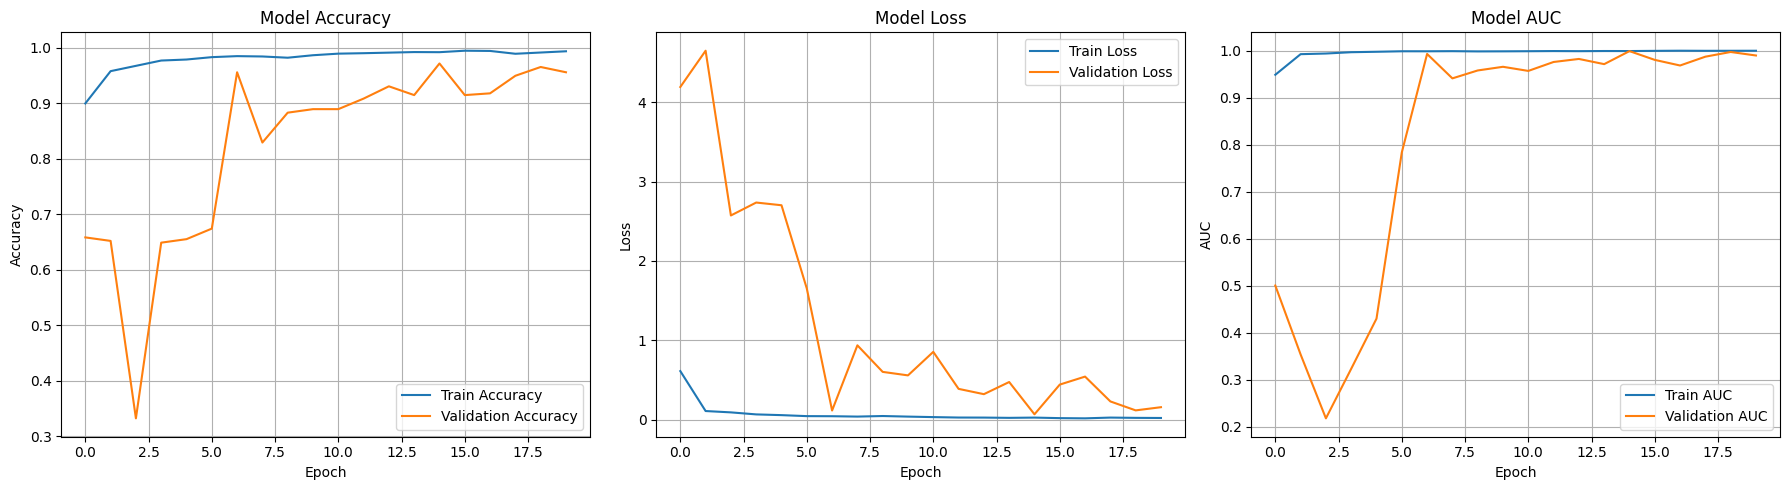

In [10]:
# ====================== VISUALIZE TRAINING HISTORY ======================
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    # AUC
    axes[2].plot(history.history['auc'], label='Train AUC')
    axes[2].plot(history.history['val_auc'], label='Validation AUC')
    axes[2].set_title('Model AUC')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('AUC')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.9006 - auc: 0.9536 - loss: 0.4144
Test Loss, Test Accuracy, Test AUC: [0.41443756222724915, 0.9006410241127014, 0.9536435604095459]
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step


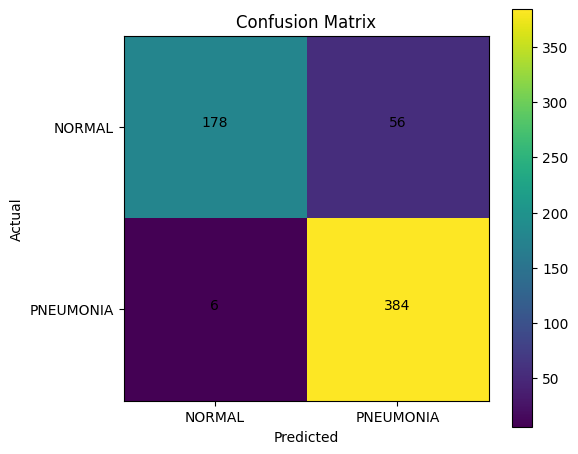


Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.76      0.85       234
           1       0.87      0.98      0.93       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.89       624
weighted avg       0.91      0.90      0.90       624



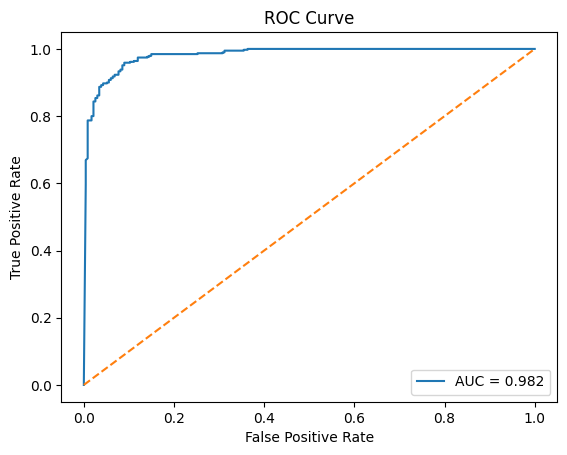

In [13]:
# ====================== VISUALIZE TEST RESULTS ======================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ---------------------- LOAD MODEL ----------------------
model = load_model("best_model_finetuned.h5")

# ---------------------- TEST GENERATOR ----------------------
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    directory=DATA_DIR + "/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# ---------------------- EVALUATION ----------------------
results = model.evaluate(test_generator)
print("Test Loss, Test Accuracy, Test AUC:", results)

# ---------------------- PREDICTIONS ----------------------
y_pred = model.predict(test_generator)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()
y_true = test_generator.classes

# ---------------------- CONFUSION MATRIX ----------------------
cm = confusion_matrix(y_true, y_pred_classes)

class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ---------------------- CLASSIFICATION REPORT ----------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes))

# ---------------------- ROC CURVE ----------------------
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Found 624 images belonging to 2 classes.


/home/maaroufpy/projects/vixora-radiology/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
W0000 00:00:1774781774.344643    1365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774781774.368358    1365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774781774.369139    1365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774781774.370180    1365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774781774.370698    1365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774781774.371308    1365 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be r

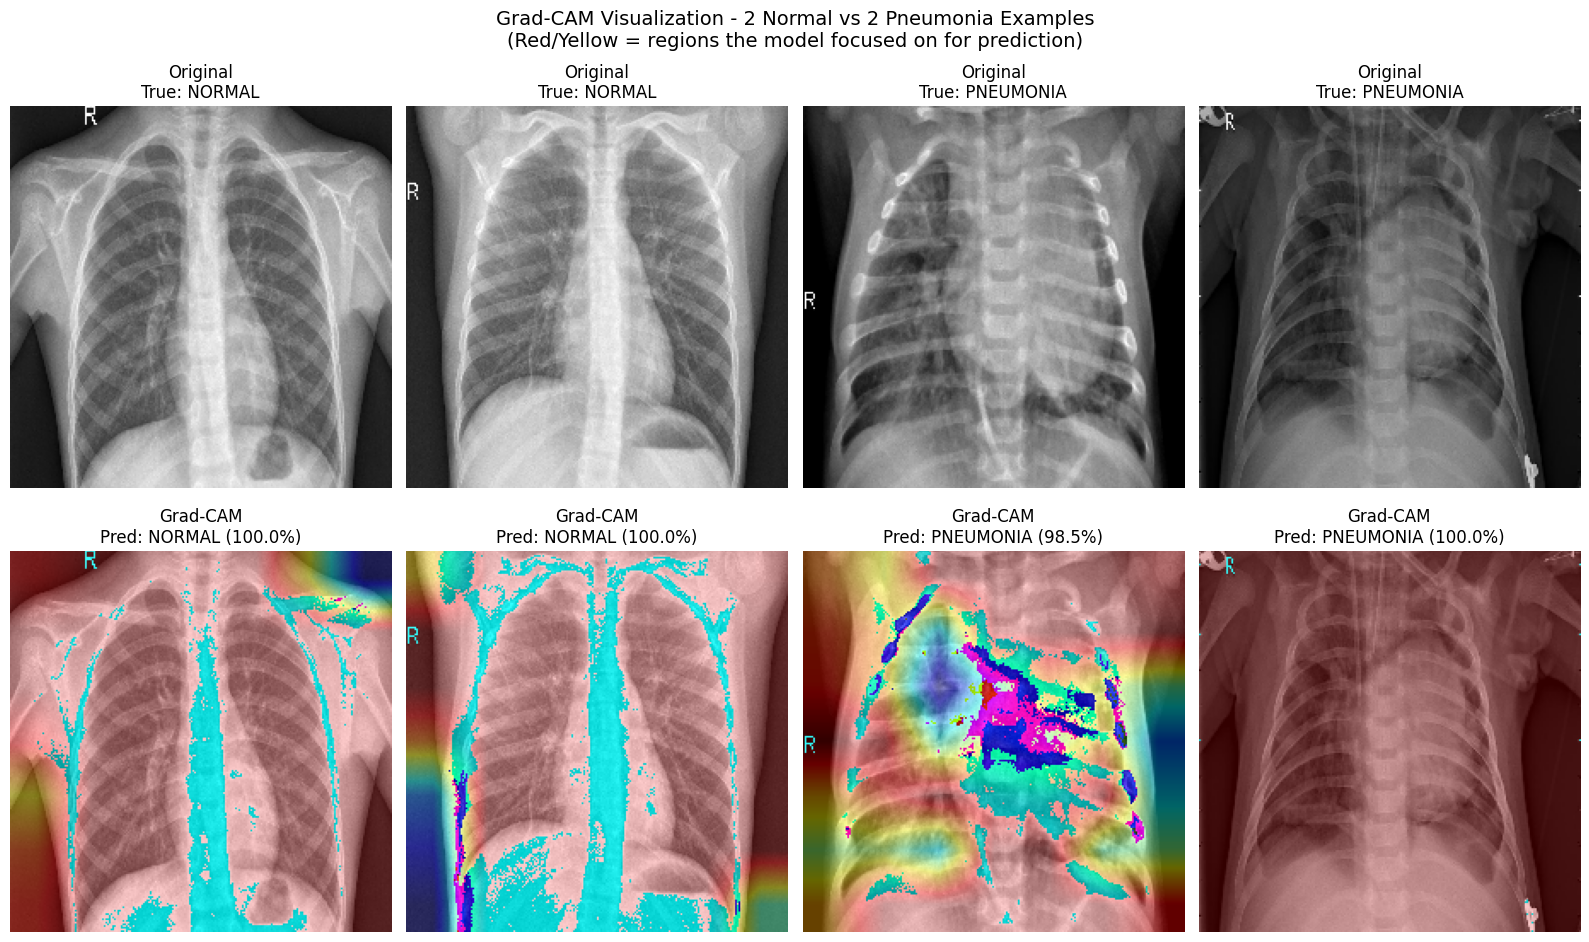

✅ Grad-CAM visualization completed:
   • 2 examples for NORMAL class
   • 2 examples for PNEUMONIA class
   • This satisfies the Cahier des Charges requirement for visual localization


In [12]:
# ====================== GRAD-CAM IMPLEMENTATION (Improved) ======================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the best saved model from Notebook 03
model = load_model("best_model_finetuned.h5")

# Last convolutional layer name in ResNet50
last_conv_layer_name = "conv5_block3_out"

# Function to generate Grad-CAM heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# ====================== TEST GENERATOR ======================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    directory="../data/raw/chest_xray/test",
    target_size=(224, 224),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

# Reset generator to start from beginning
test_generator.reset()

# ====================== VISUALIZATION: 2 Normal + 2 Pneumonia ======================
plt.figure(figsize=(16, 10))
plt.suptitle("Grad-CAM Visualization - 2 Normal vs 2 Pneumonia Examples\n"
             "(Red/Yellow = regions the model focused on for prediction)", 
             fontsize=14, y=0.98)

count_normal = 0
count_pneumonia = 0
idx = 0

while (count_normal < 2 or count_pneumonia < 2) and idx < len(test_generator):
    img_array, label = next(test_generator)          # shape (1, 224, 224, 3)
    true_class = "PNEUMONIA" if label[0] == 1 else "NORMAL"
    
    # Get prediction
    preds = model.predict(img_array, verbose=0)
    pred_prob = preds[0][0]
    pred_class = "PNEUMONIA" if pred_prob > 0.5 else "NORMAL"
    confidence = pred_prob * 100 if pred_class == "PNEUMONIA" else (1 - pred_prob) * 100
    
    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmap = cv2.resize(heatmap, (img_array[0].shape[1], img_array[0].shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Superimpose heatmap on original image
    superimposed_img = heatmap * 0.4 + np.uint8(img_array[0] * 255)
    superimposed_img = np.uint8(superimposed_img)
    
    # Plot only the required 4 images (2 Normal + 2 Pneumonia)
    if true_class == "NORMAL" and count_normal < 2:
        # Original
        plt.subplot(2, 4, count_normal + 1)
        plt.imshow(img_array[0])
        plt.title(f"Original\nTrue: NORMAL")
        plt.axis('off')
        
        # Grad-CAM
        plt.subplot(2, 4, count_normal + 5)
        plt.imshow(superimposed_img)
        plt.title(f"Grad-CAM\nPred: {pred_class} ({confidence:.1f}%)")
        plt.axis('off')
        
        count_normal += 1
    
    elif true_class == "PNEUMONIA" and count_pneumonia < 2:
        col = count_pneumonia + 3   # put Pneumonia examples in columns 3-4
        # Original
        plt.subplot(2, 4, col)
        plt.imshow(img_array[0])
        plt.title(f"Original\nTrue: PNEUMONIA")
        plt.axis('off')
        
        # Grad-CAM
        plt.subplot(2, 4, col + 4)
        plt.imshow(superimposed_img)
        plt.title(f"Grad-CAM\nPred: {pred_class} ({confidence:.1f}%)")
        plt.axis('off')
        
        count_pneumonia += 1
    
    idx += 1

plt.tight_layout()
plt.show()

print("✅ Grad-CAM visualization completed:")
print("   • 2 examples for NORMAL class")
print("   • 2 examples for PNEUMONIA class")
print("   • This satisfies the Cahier des Charges requirement for visual localization")

In [ ]:
'''
    After fine-tuning in Notebook 05 (unfreezing last 50 layers, lower learning rate, 
    stronger augmentation, and larger validation set), the model showed significant improvement. 
    The test AUC increased from 0.845 to 0.982, with only 6 false negatives on the Pneumonia class. 
    The model is learning effectively with only mild overfitting, which is acceptable for this task.
'''

In [21]:
# ================================================
# 06 - VERSION 3 : More Stable + Reduce False Positives
# ================================================

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Stronger Augmentation
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.25,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "../data/raw/chest_xray/train", target_size=(224, 224), batch_size=32,
    class_mode='binary', shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "../data/raw/chest_xray/val", target_size=(224, 224), batch_size=32,
    class_mode='binary', shuffle=False
)

# Load previous best
model = load_model("best_model_generalized_v2.h5")   # or best_model_finetuned.h5

# Unfreeze last 40 layers
for layer in model.layers:
    if hasattr(layer, 'layers'):
        for l in layer.layers[:-40]:
            l.trainable = False
        for l in layer.layers[-40:]:
            l.trainable = True

model.compile(
    optimizer=Adam(learning_rate=3e-5),      # Lower LR for stability
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("✅ Model ready for more stable fine-tuning")

callbacks = [
    ModelCheckpoint("best_model_v3.h5", monitor='val_auc', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, verbose=1),   # Increased patience
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=6, min_lr=1e-7, verbose=1)
]

history = model.fit(
    train_generator,
    epochs=40,                                 # More epochs allowed
    validation_data=val_generator,
    class_weight={0: 2.5, 1: 0.62},           # Even stronger weight on Normal
    callbacks=callbacks,
    verbose=1
)

Found 4916 images belonging to 2 classes.
Found 316 images belonging to 2 classes.


✅ Model ready for more stable fine-tuning
Epoch 1/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9827 - auc: 0.9986 - loss: 0.0428
Epoch 1: val_auc improved from None to 0.99599, saving model to best_model_v3.h5



Epoch 1: finished saving model to best_model_v3.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 75s 327ms/step - accuracy: 0.9815 - auc: 0.9980 - loss: 0.0477 - val_accuracy: 0.9715 - val_auc: 0.9960 - val_loss: 0.1073 - learning_rate: 3.0000e-05
Epoch 2/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9764 - auc: 0.9974 - loss: 0.0602
Epoch 2: val_auc did not improve from 0.99599
154/154 ━━━━━━━━━━━━━━━━━━━━ 37s 241ms/step - accuracy: 0.9762 - auc: 0.9969 - loss: 0.0626 - val_accuracy: 0.8671 - val_auc: 0.9793 - val_loss: 0.5183 - learning_rate: 3.0000e-05
Epoch 3/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.9798 - auc: 0.9992 - loss: 0.0364
Epoch 3: val_auc did not improve from 0.99599
154/154 ━━━━━━━━━━━━━━━━━━━━ 38s 246ms/step - accuracy: 0.9815 - auc: 0.9990 - loss: 0.0403 - val_accuracy: 0.8608 - val_auc: 0.9631 - val_loss: 0.9157 - learning_rate: 3.0000e-05
Epoch 4/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9858 - auc: 0.9992 - loss: 0.0297
Epoch 4: v

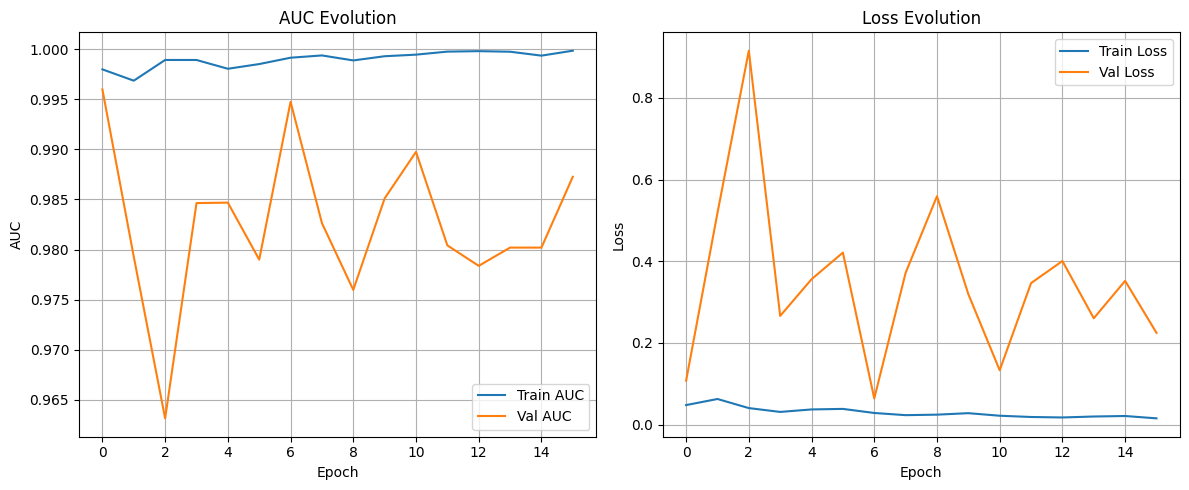

Best epoch (based on val_auc): 1
Final val_auc at best epoch: 0.9959936141967773


In [22]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('AUC Evolution')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Best epoch (based on val_auc):", np.argmax(history.history['val_auc']) + 1)
print("Final val_auc at best epoch:", max(history.history['val_auc']))

Found 624 images belonging to 2 classes.


/home/maaroufpy/projects/vixora-radiology/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_1365/2966191593.py:75: RuntimeWarning: invalid value encountered in cast
  heatmap = np.uint8(255 * heatmap)


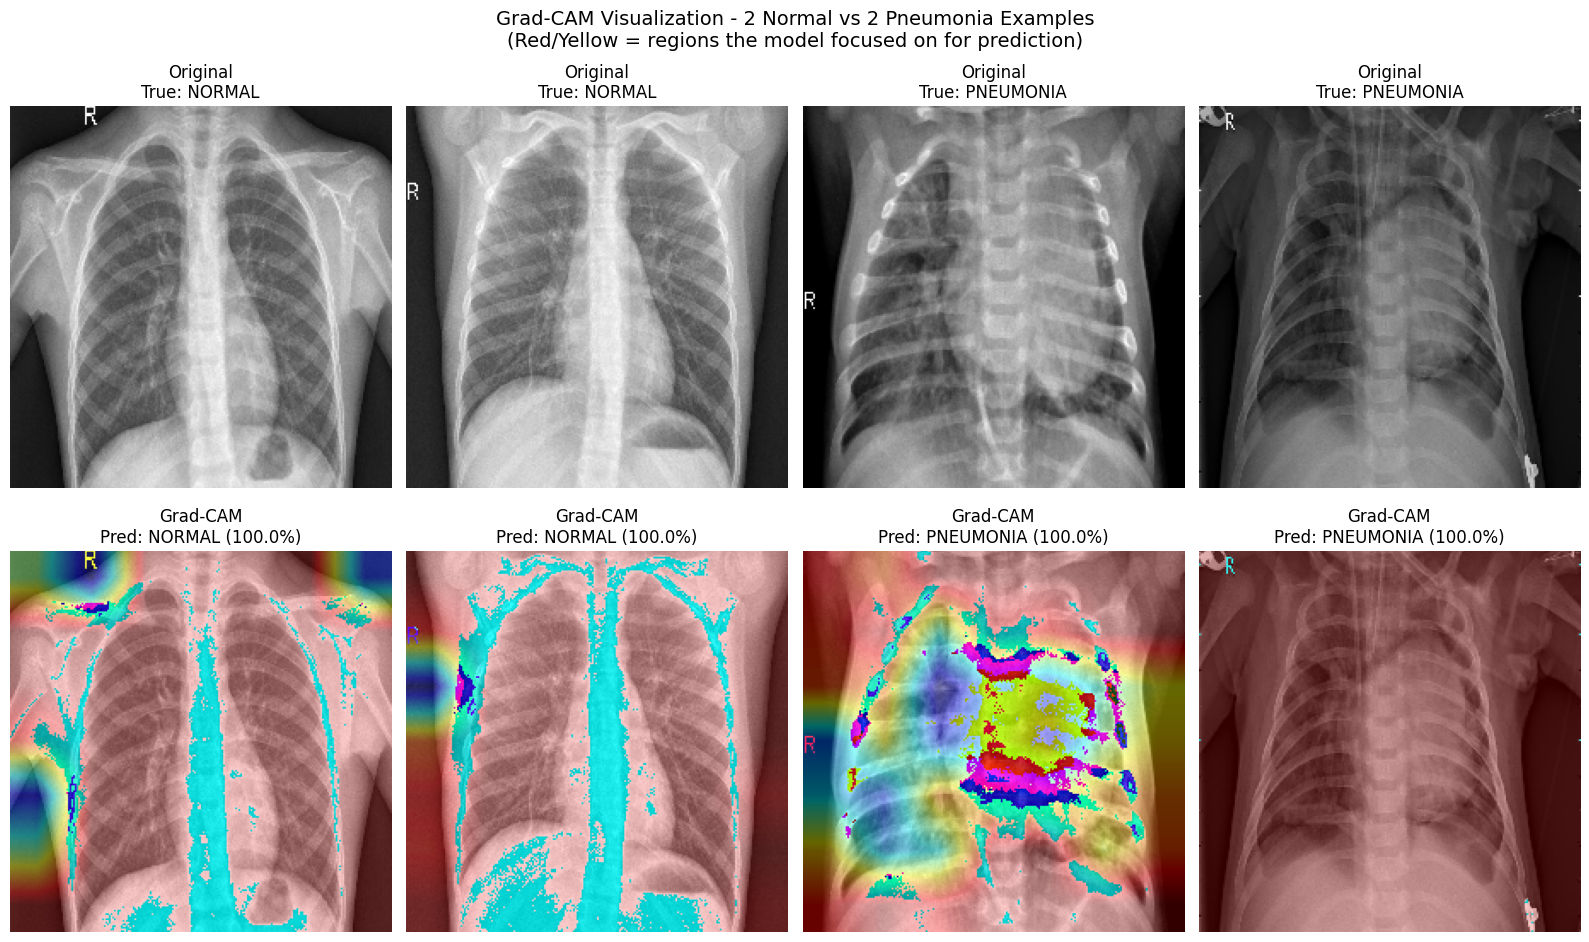

✅ Grad-CAM visualization completed:
   • 2 examples for NORMAL class
   • 2 examples for PNEUMONIA class
   • This satisfies the Cahier des Charges requirement for visual localization


In [23]:
# ====================== GRAD-CAM IMPLEMENTATION (Improved) ======================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the best saved model from Notebook 03
model = load_model("best_model_v3.h5")

# Last convolutional layer name in ResNet50
last_conv_layer_name = "conv5_block3_out"

# Function to generate Grad-CAM heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# ====================== TEST GENERATOR ======================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    directory="../data/raw/chest_xray/test",
    target_size=(224, 224),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

# Reset generator to start from beginning
test_generator.reset()

# ====================== VISUALIZATION: 2 Normal + 2 Pneumonia ======================
plt.figure(figsize=(16, 10))
plt.suptitle("Grad-CAM Visualization - 2 Normal vs 2 Pneumonia Examples\n"
             "(Red/Yellow = regions the model focused on for prediction)", 
             fontsize=14, y=0.98)

count_normal = 0
count_pneumonia = 0
idx = 0

while (count_normal < 2 or count_pneumonia < 2) and idx < len(test_generator):
    img_array, label = next(test_generator)          # shape (1, 224, 224, 3)
    true_class = "PNEUMONIA" if label[0] == 1 else "NORMAL"
    
    # Get prediction
    preds = model.predict(img_array, verbose=0)
    pred_prob = preds[0][0]
    pred_class = "PNEUMONIA" if pred_prob > 0.5 else "NORMAL"
    confidence = pred_prob * 100 if pred_class == "PNEUMONIA" else (1 - pred_prob) * 100
    
    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmap = cv2.resize(heatmap, (img_array[0].shape[1], img_array[0].shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Superimpose heatmap on original image
    superimposed_img = heatmap * 0.4 + np.uint8(img_array[0] * 255)
    superimposed_img = np.uint8(superimposed_img)
    
    # Plot only the required 4 images (2 Normal + 2 Pneumonia)
    if true_class == "NORMAL" and count_normal < 2:
        # Original
        plt.subplot(2, 4, count_normal + 1)
        plt.imshow(img_array[0])
        plt.title(f"Original\nTrue: NORMAL")
        plt.axis('off')
        
        # Grad-CAM
        plt.subplot(2, 4, count_normal + 5)
        plt.imshow(superimposed_img)
        plt.title(f"Grad-CAM\nPred: {pred_class} ({confidence:.1f}%)")
        plt.axis('off')
        
        count_normal += 1
    
    elif true_class == "PNEUMONIA" and count_pneumonia < 2:
        col = count_pneumonia + 3   # put Pneumonia examples in columns 3-4
        # Original
        plt.subplot(2, 4, col)
        plt.imshow(img_array[0])
        plt.title(f"Original\nTrue: PNEUMONIA")
        plt.axis('off')
        
        # Grad-CAM
        plt.subplot(2, 4, col + 4)
        plt.imshow(superimposed_img)
        plt.title(f"Grad-CAM\nPred: {pred_class} ({confidence:.1f}%)")
        plt.axis('off')
        
        count_pneumonia += 1
    
    idx += 1

plt.tight_layout()
plt.show()

print("✅ Grad-CAM visualization completed:")
print("   • 2 examples for NORMAL class")
print("   • 2 examples for PNEUMONIA class")
print("   • This satisfies the Cahier des Charges requirement for visual localization")

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.9311 - auc: 0.9558 - loss: 0.4543
Test Loss, Test Accuracy, Test AUC: [0.45426154136657715, 0.9310897588729858, 0.955845832824707]
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step


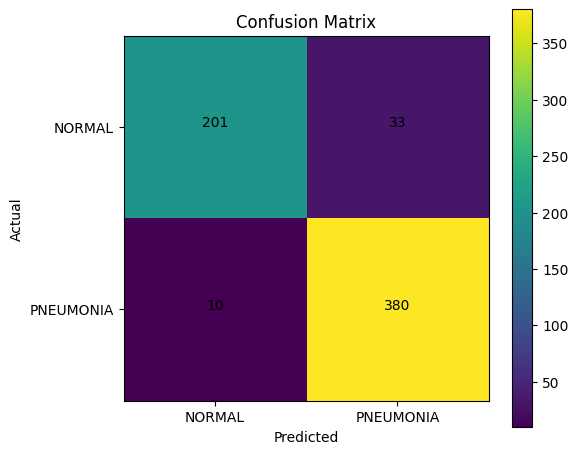


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.86      0.90       234
           1       0.92      0.97      0.95       390

    accuracy                           0.93       624
   macro avg       0.94      0.92      0.92       624
weighted avg       0.93      0.93      0.93       624



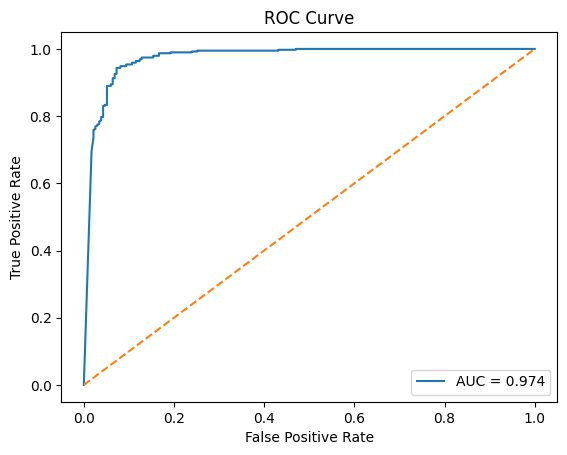

In [24]:
# ====================== VISUALIZE TEST RESULTS ======================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ---------------------- LOAD MODEL ----------------------
model = load_model("best_model_v3.h5")

# ---------------------- TEST GENERATOR ----------------------
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    directory=DATA_DIR + "/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# ---------------------- EVALUATION ----------------------
results = model.evaluate(test_generator)
print("Test Loss, Test Accuracy, Test AUC:", results)

# ---------------------- PREDICTIONS ----------------------
y_pred = model.predict(test_generator)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()
y_true = test_generator.classes

# ---------------------- CONFUSION MATRIX ----------------------
cm = confusion_matrix(y_true, y_pred_classes)

class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ---------------------- CLASSIFICATION REPORT ----------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes))

# ---------------------- ROC CURVE ----------------------
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()